In [1]:
import scipy

from src.utils import ingaas_processing
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#scan_path = "F://Work//LIPI//scans//scan_20260226_152601.raw"
scan_path = "C://Users//jeppe//Documents//LIPI//scans//test2//scan_20260226_152601.raw"
cal_path = "data/calibration.npz"
K,P,DIM = ingaas_processing.load_calibration(cal_path)
scan = np.array(ingaas_processing.undistort(ingaas_processing.load_raw_image(scan_path, 640, 512), K, P, DIM))

280


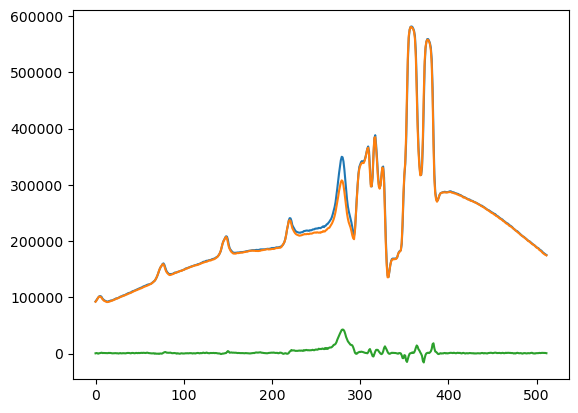

In [3]:
frame_profile = np.sum(scan, axis=2)
plt.plot(frame_profile[4001])
plt.plot(frame_profile[4000])
plt.plot(frame_profile[4001]-frame_profile[4000])
print(np.argmax(frame_profile[4001]-frame_profile[4000]))

279.0 279 4482
(array([118, 122, 127, 129, 131, 135, 147, 149, 151, 153, 154, 156, 157,
       160, 162, 163, 164, 165, 167, 168, 169, 171, 233, 238, 244, 245,
       248, 249, 250, 253, 254, 255, 256, 257, 258, 260, 261, 262, 263,
       264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276,
       277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289,
       290, 291, 310, 311, 312, 313, 315, 316, 327, 328, 329, 333, 349,
       350, 351, 352, 353, 364, 365, 371, 372, 380, 381, 382, 383, 384,
       385, 386, 387, 388, 389, 390, 391, 392, 395, 396, 397, 398, 400,
       401, 402, 404, 405, 406, 410, 442, 447, 448, 449, 451, 455, 461,
       464, 466, 469, 470, 473, 475, 477, 481], dtype=int64), array([   1,    2,    1,    2,    1,    1,    1,    1,    2,    2,    1,
          2,    1,    1,    1,    1,    2,    1,    1,    1,    1,    1,
          1,    1,    1,    2,    1,    1,    1,    1,    1,    3,    1,
          1,    2,    1,    1,    1,    6,    1,    4, 

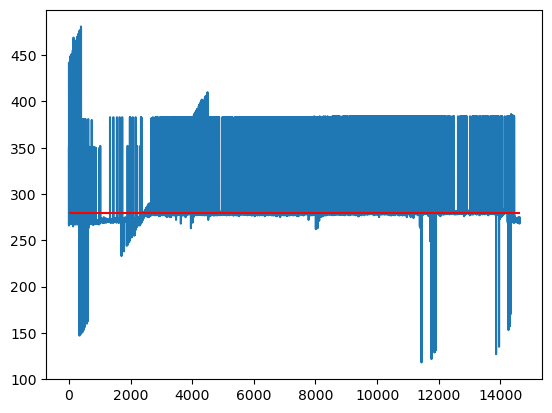

In [4]:
test = np.argmax(np.abs(frame_profile[1:]-frame_profile[:-1]), axis=1)
test_2 = np.unique(test, return_counts=True)
print(np.median(test), test_2[0][np.argmax(test_2[1])], np.max(test_2[1]))
print(test_2)
plt.plot(test)
plt.hlines(280, 0, scan.shape[0], "r")

In [5]:
print(np.min(scan), np.max(scan), scan.shape, scan.dtype)
plt.imshow(scan[4002])
plt.hlines(279, 0, 640, "r")

KeyboardInterrupt: 

In [6]:
scan_profile = frame_profile[:,279]

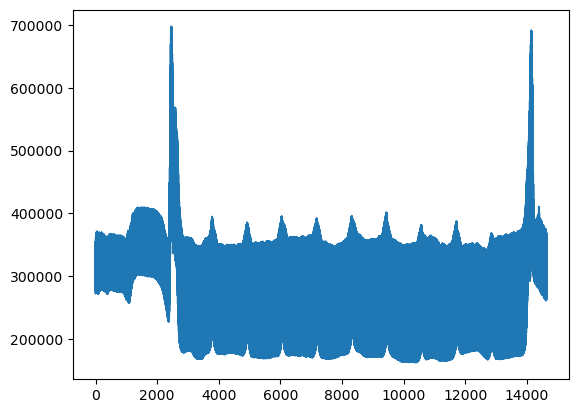

In [7]:
plt.plot(scan_profile)

2460 14133


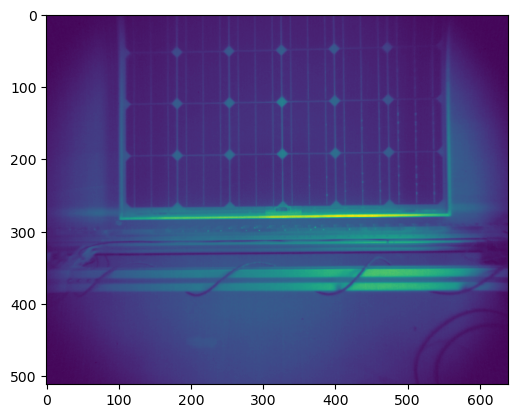

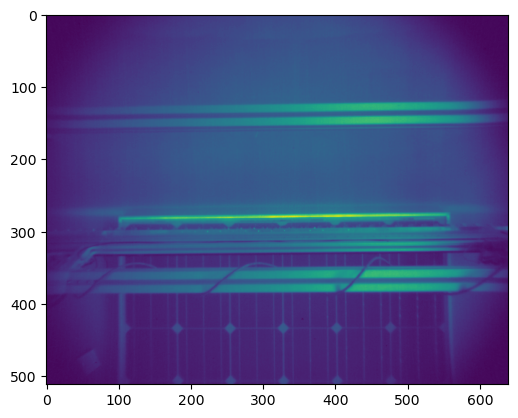

In [67]:
peaks, properties = scipy.signal.find_peaks(scan_profile, prominence=0, wlen=1000)
sorted_index = np.argsort(properties["prominences"])
peak_1 = peaks[sorted_index[-1]]
peak_2 = peaks[sorted_index[-2]]
print(peak_1, peak_2)
module_start = min(peak_1, peak_2)
module_end = max(peak_1, peak_2)
plt.imshow(scan[module_start])
plt.show()
plt.imshow(scan[module_end])
plt.show()

[[ 6.60779098e-04  1.32155820e-03  6.60779098e-04  1.00000000e+00
  -1.92598397e+00  9.28627086e-01]]
2494 2494
1.381686778616313 229.94646240284374


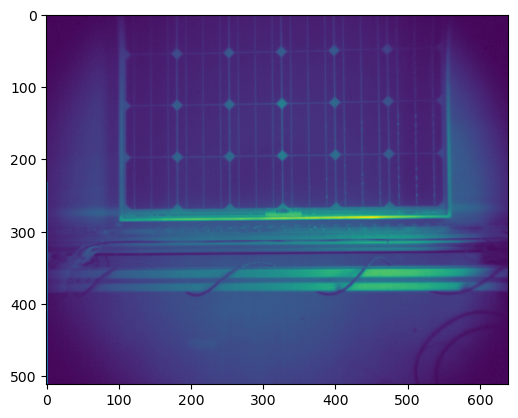

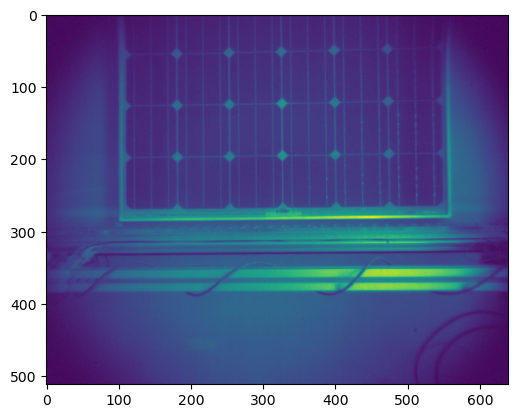

In [65]:
# #scipy envelope??
# #low pass filter or something to detect the large peaks then remove start and end of module for further analysis of the scan
#
# coffs = scipy.signal.butter(2, 1/60, output="sos", btype="lowpass")
# print(coffs)
# low_pass = scipy.signal.sosfilt(coffs, scan_profile)
# plt.plot(low_pass)
#
# peaks, properties = scipy.signal.find_peaks(low_pass, width=0, height=0)
# #plt.plot(peaks, scan_profile[peaks], ".")
# #print(properties["peak_heights"])
# sorted_index = np.argsort(properties["peak_heights"])
# module_start = min(peaks[sorted_index[-1]], peaks[sorted_index[-2]])
# module_end = max(peaks[sorted_index[-2]], peaks[sorted_index[-2]])
# #test_width = int(properties["widths"][sorted_index[-1]])
# print(module_start, module_end)
# plt.vlines((module_start, module_end), 0, np.max(low_pass), "r")
# width_end = properties["widths"][sorted_index[-1]]
# width_start = properties["widths"][sorted_index[-2]]
# print(width_start, width_end)
# plt.vlines((module_start+width_start, module_end-width_end), 0, np.max(low_pass), "g")
#
# plt.imshow(scan[int(module_start+width_start)])
# plt.show()
# plt.imshow(scan[int(module_end-width_start)+2])

[0.         0.00333425 0.0066685  ... 0.00338262 0.00671687 0.01005112]


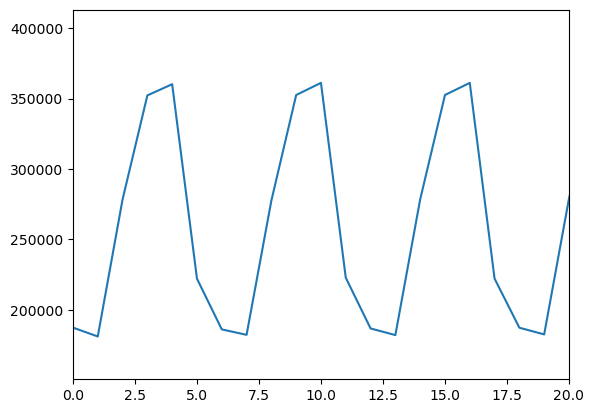

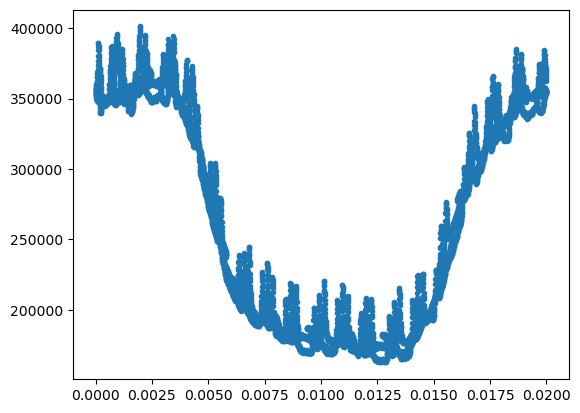

In [68]:
f_m = 50
#f_s = 300
f_s = 299.917668
#print(1/f_m, 6/f_s)
times = (np.arange(scan_profile.shape[0])/f_s) % (1/f_m)
print(times)
sorted_time = np.argsort(times)
trim_start = module_start+500
trim_end = module_end-500
trimmed_profile = scan_profile[trim_start:trim_end]
#plt.plot(trimmed_profile)
#plt.hlines(np.mean(trimmed_profile), 0, 10000, "r")
#binary = np.zeros_like(trimmed_profile)
#binary[trimmed_profile>np.median(trimmed_profile)] = 1
plt.plot(trimmed_profile)
plt.xlim(0, 20)
plt.show()
#to = 18
plt.plot(times[trim_start:trim_end], scan_profile[trim_start:trim_end], ".")

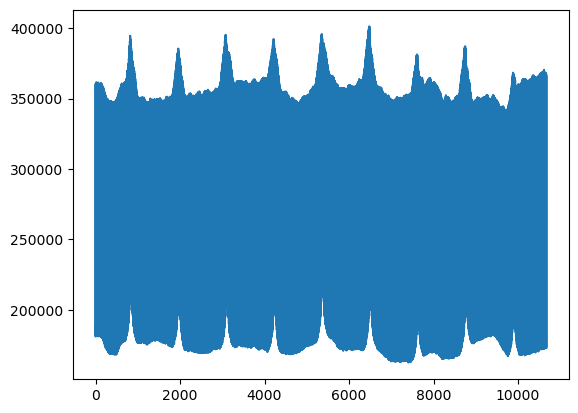

In [15]:
6plt.plot(trimmed_profile)

[   2    4    7   17   19   24   26   28   35   37   39   42   44   47
   49   54   59   63   66   69   72   75   77   80   82   85   90   92
   96  100  103  105  110  113  115  117  119  121  124  126  129  132
  150  152  160  165  173  178  184  186  188  191  195  198  202  204
  209  212  214  216  221  224  228  233  237  239  242  244  247  250
  253  257  261  264  266  269  271  274  276  280  282  286  288  291
  293  295  299  351  371  373  380  431  441  443  447  449  452  477
  481  503  508  514  516  519  548  550  554  557  561  575  580  584
  586  588  590  594  597  603  608  610  615  620  629  633  636  639
  642  644  648  651  653  655  662  666  669  671  675  679  712  714
  717  719  722  741  743  748  751  755  757  759  763  766  769  773
  777  779  782  788  791  796  799  803  806  808  810  813  816  821
  827  829  832  834  838  842  845  847  875  885  889  894  896  899
  904  909  912  915  917  919  923  928  930  934  937  940  943  946
  948 

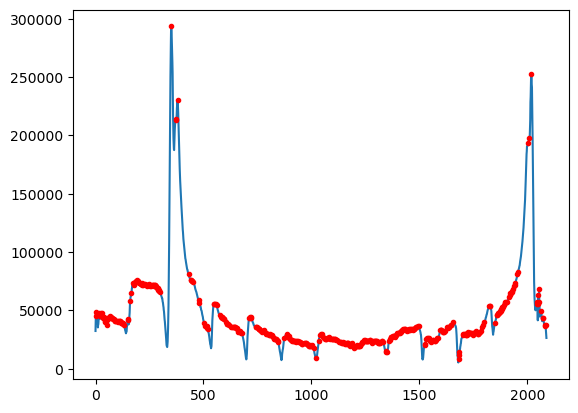

In [87]:
#bp_in = (6, None)
test = scipy.signal.envelope(scan_profile, n_out = int(len(scan_profile)/7))
#plt.plot(scan_profile[trim_start:trim_start+12])
plt.plot(test[0])
peaks_test, _ = scipy.signal.find_peaks(test[0])
print(peaks_test)
plt.plot(peaks_test, test[0][peaks_test], ".r")